<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# EPC-Based Energy Consumption Prediction Using Random Forest

The RF pipeline automatically **imputes missing values, scales numerical variables, encodes categorical variables, and trains a Random Forest model** to predict current energy consumption. The model achieves an **R² score of 0.9068** on the test data. 

## Random Forest (RF) Pipeline

The notebook uses a **Scikit-learn Pipeline** that combines data preprocessing with a **Random Forest Regressor**.

### Pipeline Workflow

**Raw EPC data → Preprocessing → Random Forest → Energy consumption prediction**

### 1. Numerical Features
- Missing values are replaced using **median imputation**.
- Features are standardised using **StandardScaler**.

### 2. Categorical Features
- Missing values are replaced using the **most frequent value**.
- Categorical variables are converted using **OneHotEncoder**.
- Unknown categories are ignored during prediction.

### 3. ColumnTransformer
A `ColumnTransformer` applies the appropriate preprocessing steps separately to numerical and categorical features.

### 4. Random Forest Regressor

The model uses:
- `n_estimators = 100`
- `max_depth = 20`
- `random_state = 42`
- `n_jobs = -1`

The target variable is **`energy_consumption_current`**.

### 5. Training and Evaluation
- **80%** of the data is used for training.
- **20%** is used for testing.
- The trained pipeline predicts energy consumption on the test set.

### 6. Model Performance

| Metric | Score |
|---|---:|
| **R²** | **0.9068** |
| **MAE** | **11.0807** |
| **RMSE** | **33.6915** |

## Limitations 

- **Single train–test split:** The model uses an 80/20 split, without cross-validation, so performance may depend on the particular split.

- **Limited hyperparameter tuning:** The Random Forest uses fixed parameters (`100` trees and `max_depth=20`) without systematic optimisation.

- **No model comparison:** The notebook evaluates only Random Forest and does not compare it with other machine-learning models.

- **Potential target leakage:** `current_energy_efficiency` is the most important feature (**68.4% importance**), so its relationship with the target should be investigated to ensure that information unavailable at prediction time is not being used.

- **Limited interpretability:** Feature importance identifies influential variables but does not clearly explain how each feature affects energy consumption.

- **No uncertainty estimation:** The notebook provides point predictions but does not calculate prediction intervals or uncertainty estimates.

- **Limited generalisation:** The dataset is based on Sheffield EPC data, so the model's performance may not generalise to other locations or housing populations.

- **Limited error analysis:** Although MAE and RMSE are reported, the notebook does not provide a detailed investigation of large prediction errors or model residuals.

- **Limited feature selection:** The notebook does not perform systematic feature selection or investigate feature redundancy.

## Applicability to Real-World Studies

- **Energy consumption prediction:** The model can be used to estimate current energy consumption from property characteristics and energy-efficiency information.

- **Property-level assessment:** EPC features such as floor area, energy efficiency, heating systems, building age, and number of rooms can support energy-performance assessments of individual properties.

- **Energy-efficiency planning:** The identified important features can help researchers and policymakers understand which property characteristics are strongly associated with energy consumption.

- **Large-scale analysis:** With more than 200,000 EPC records, the approach demonstrates the potential for machine-learning models to analyse large property datasets efficiently.

- **Policy and intervention support:** Predictions could potentially support the identification of properties with higher energy consumption and help target energy-efficiency improvements.

- **Model deployment:** The preprocessing and Random Forest model are combined into a single pipeline, making the workflow suitable for applying the same transformations to new property data.

- **Geographical limitation:** The current study is based on Sheffield EPC data, so further validation is required before applying the model to other regions.

- **Real-world validation required:** Before practical deployment, the model should be tested on independent and more recent data to assess its reliability and generalisability.

- **Potential data-leakage concern:** The use of `current_energy_efficiency` as a highly influential predictor should be carefully assessed to ensure that all input variables would be available when making real-world predictions.

### Overall

The notebook provides a useful **proof of concept for applying Random Forest regression to real-world EPC data**. Its strong test performance suggests potential for energy-consumption prediction and energy-efficiency analysis, but external validation, leakage assessment, and further model development would be needed before operational use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# 1. Load Data
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')

# 2. Drop specified columns
cols_to_drop = ['certificate_number', 'postcode', 'constituency_label', 'constituency']
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209230 entries, 0 to 209229
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   energy_consumption_current    209230 non-null  float64
 1   total_floor_area              209230 non-null  int64  
 2   current_energy_efficiency     209230 non-null  int64  
 3   current_energy_rating         209230 non-null  object 
 4   number_heated_rooms           190272 non-null  float64
 5   number_habitable_rooms        190272 non-null  float64
 6   low_energy_lighting           209216 non-null  float64
 7   tenure                        201474 non-null  object 
 8   property_type                 209228 non-null  object 
 9   construction_age_band         190523 non-null  object 
 10  built_form                    207737 non-null  object 
 11  flat_storey_count             205000 non-null  float64
 12  lighting_cost_current         209230 non-nul

In [3]:
df_model.head(5)

,energy_consumption_current,total_floor_area,current_energy_efficiency,current_energy_rating,number_heated_rooms,number_habitable_rooms,low_energy_lighting,tenure,property_type,construction_age_band,...,multi_glaze_proportion,hot_water_energy_eff,roof_energy_eff,walls_energy_eff,windows_energy_eff,mainheat_energy_eff,mainheatc_energy_eff,lighting_energy_eff,fixed_lighting_outlets_count,floor_height
0,245.0,79,64,D,5.0,5.0,100.0,owner-occupied,House,England and Wales: 1900-1929,...,100.0,Good,Average,Very Poor,Poor,Good,Good,Good,16.0,3.01
1,247.0,76,64,D,5.0,5.0,100.0,owner-occupied,House,England and Wales: 1930-1949,...,100.0,Good,Good,Poor,Poor,Good,Good,Very Good,20.0,2.44
2,214.0,145,58,D,7.0,7.0,77.0,owner-occupied,House,England and Wales: 1930-1949,...,100.0,Good,Average,Good,Poor,Good,Good,Poor,26.0,2.51
3,145.0,43,74,C,2.0,2.0,71.0,rented (social),Flat,England and Wales: 1967-1975,...,100.0,Good,Very Good,Good,Average,Good,Poor,Poor,7.0,2.37
4,182.0,92,71,C,4.0,4.0,100.0,rented (social),House,England and Wales: 1950-1966,...,100.0,Good,Average,Good,Poor,Good,Good,Good,8.0,2.45


In [4]:
# 3. Define Target and Predictors
target = 'energy_consumption_current'
X = df_model.drop(columns=[target])
y = df_model[target]

# 4. Identify Feature Types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [5]:
# 5. Build Pipelines with ColumnTransformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1))
])

In [6]:
# 6. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_pipeline.fit(X_train, y_train)

# 7. Evaluate
y_pred = rf_pipeline.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R² Score: 0.9068
MAE: 11.0807
RMSE: 33.6915


In [7]:
# Feature Importance Analysis
ohe_feature_names = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_cols)
all_feature_names = list(numeric_cols) + list(ohe_feature_names)

importances = rf_pipeline.named_steps['regressor'].feature_importances_
fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
fi_df = fi_df.sort_values(by='importance', ascending=False)

print("Top 15 Most Important Features:")
print(fi_df.head(15))

Top 15 Most Important Features:
                         feature  importance
1      current_energy_efficiency    0.683899
0               total_floor_area    0.138531
6          lighting_cost_current    0.053946
85   mainheat_energy_eff_Average    0.023838
3         number_habitable_rooms    0.011131
7           heating_cost_current    0.008437
19         tenure_Owner-occupied    0.008172
8         hot_water_cost_current    0.007935
86      mainheat_energy_eff_Good    0.006497
63       built_form_Not Recorded    0.006403
10  fixed_lighting_outlets_count    0.003782
92     mainheatc_energy_eff_Poor    0.003555
16       current_energy_rating_E    0.002798
15       current_energy_rating_D    0.002609
11                  floor_height    0.002583


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
residuals = y_test - y_pred

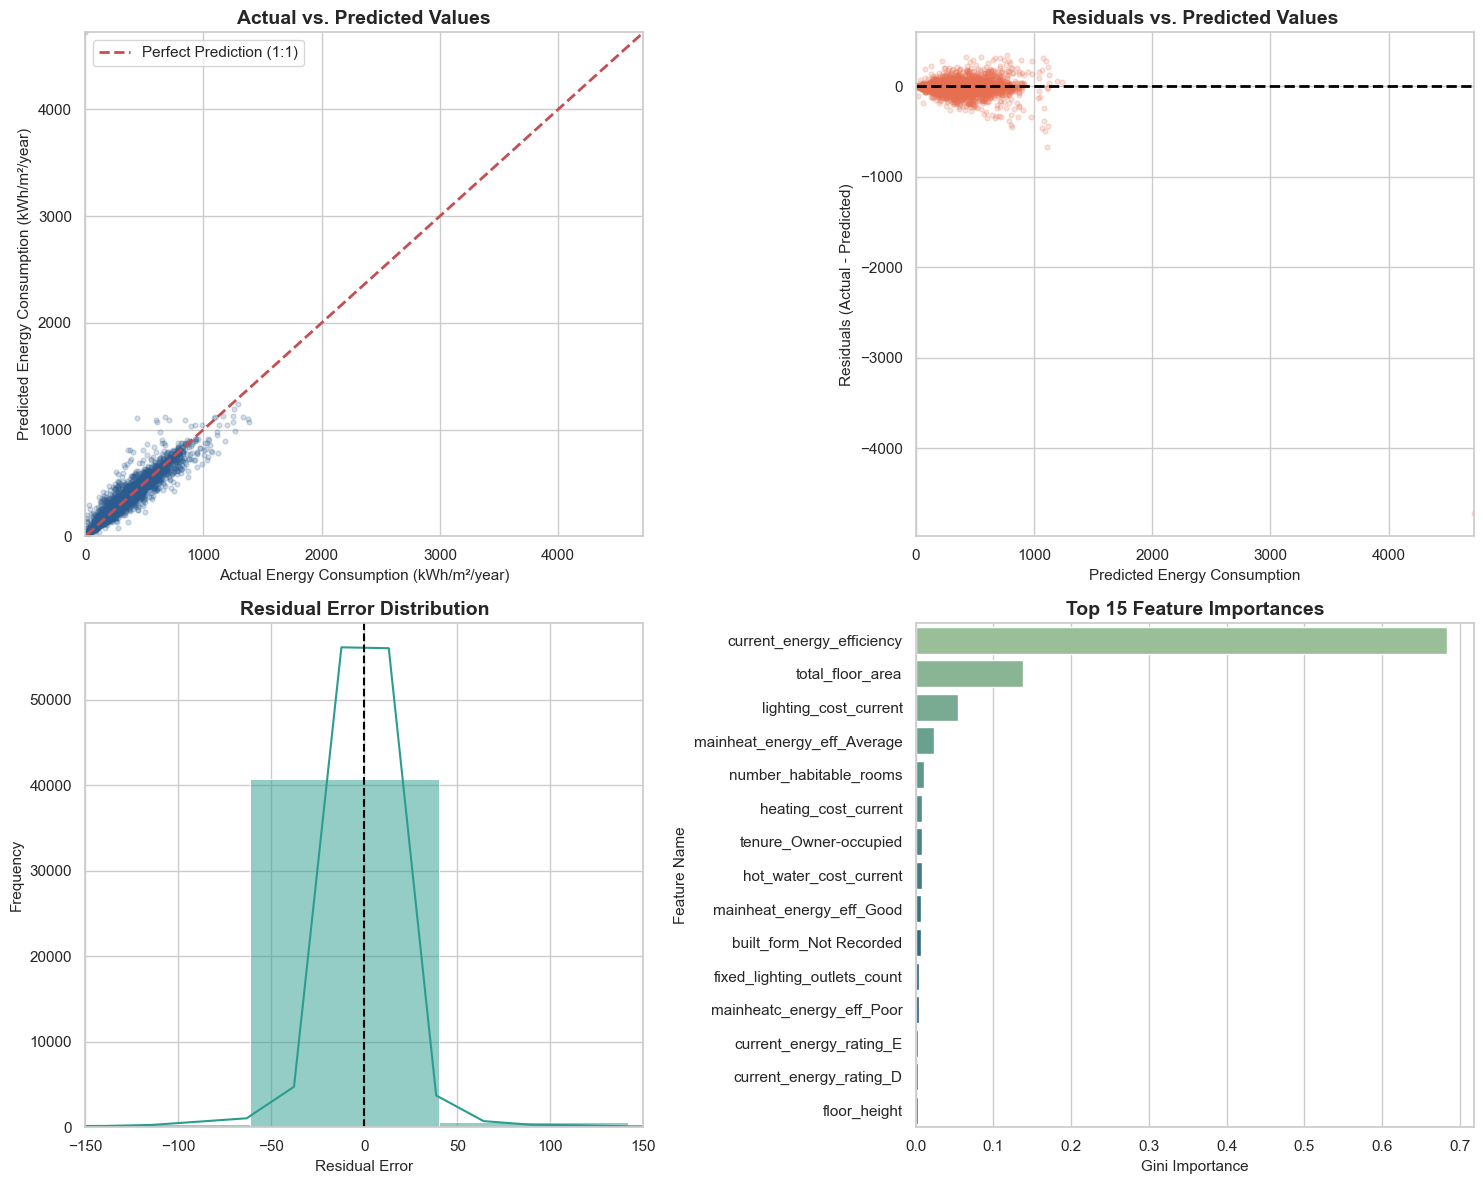

In [9]:
# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.2, color='#2b5c8f', s=12)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[0, 0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    lw=2,
    label='Perfect Prediction (1:1)'
)

axes[0, 0].set_title(
    'Actual vs. Predicted Values',
    fontsize=14,
    fontweight='bold'
)
axes[0, 0].set_xlabel(
    'Actual Energy Consumption (kWh/m²/year)',
    fontsize=11
)
axes[0, 0].set_ylabel(
    'Predicted Energy Consumption (kWh/m²/year)',
    fontsize=11
)
axes[0, 0].legend()
axes[0, 0].set_xlim(0, max_val)
axes[0, 0].set_ylim(0, max_val)


# 2. Residuals vs Predicted Plot
axes[0, 1].scatter(
    y_pred,
    residuals,
    alpha=0.2,
    color='#e76f51',
    s=12
)

axes[0, 1].axhline(
    y=0,
    color='black',
    linestyle='--',
    lw=2
)

axes[0, 1].set_title(
    'Residuals vs. Predicted Values',
    fontsize=14,
    fontweight='bold'
)
axes[0, 1].set_xlabel(
    'Predicted Energy Consumption',
    fontsize=11
)
axes[0, 1].set_ylabel(
    'Residuals (Actual - Predicted)',
    fontsize=11
)
axes[0, 1].set_xlim(0, max_val)


# 3. Residual Distribution
sns.histplot(
    residuals,
    kde=True,
    ax=axes[1, 0],
    color='#2a9d8f',
    bins=50
)

axes[1, 0].axvline(
    x=0,
    color='black',
    linestyle='--',
    lw=1.5
)

axes[1, 0].set_title(
    'Residual Error Distribution',
    fontsize=14,
    fontweight='bold'
)
axes[1, 0].set_xlabel(
    'Residual Error',
    fontsize=11
)
axes[1, 0].set_ylabel(
    'Frequency',
    fontsize=11
)
axes[1, 0].set_xlim(-150, 150)


# 4. Top 15 Feature Importances
ohe_feature_names = (
    rf_pipeline
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)

all_feature_names = list(numeric_cols) + list(ohe_feature_names)

importances = (
    rf_pipeline
    .named_steps['regressor']
    .feature_importances_
)

fi_df = (
    pd.DataFrame({
        'feature': all_feature_names,
        'importance': importances
    })
    .sort_values(by='importance', ascending=False)
    .head(15)
)

# Fixed Seaborn FutureWarning
sns.barplot(
    data=fi_df,
    x='importance',
    y='feature',
    hue='feature',
    palette='crest',
    legend=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    'Top 15 Feature Importances',
    fontsize=14,
    fontweight='bold'
)
axes[1, 1].set_xlabel(
    'Gini Importance',
    fontsize=11
)
axes[1, 1].set_ylabel(
    'Feature Name',
    fontsize=11
)

plt.tight_layout()
plt.show()

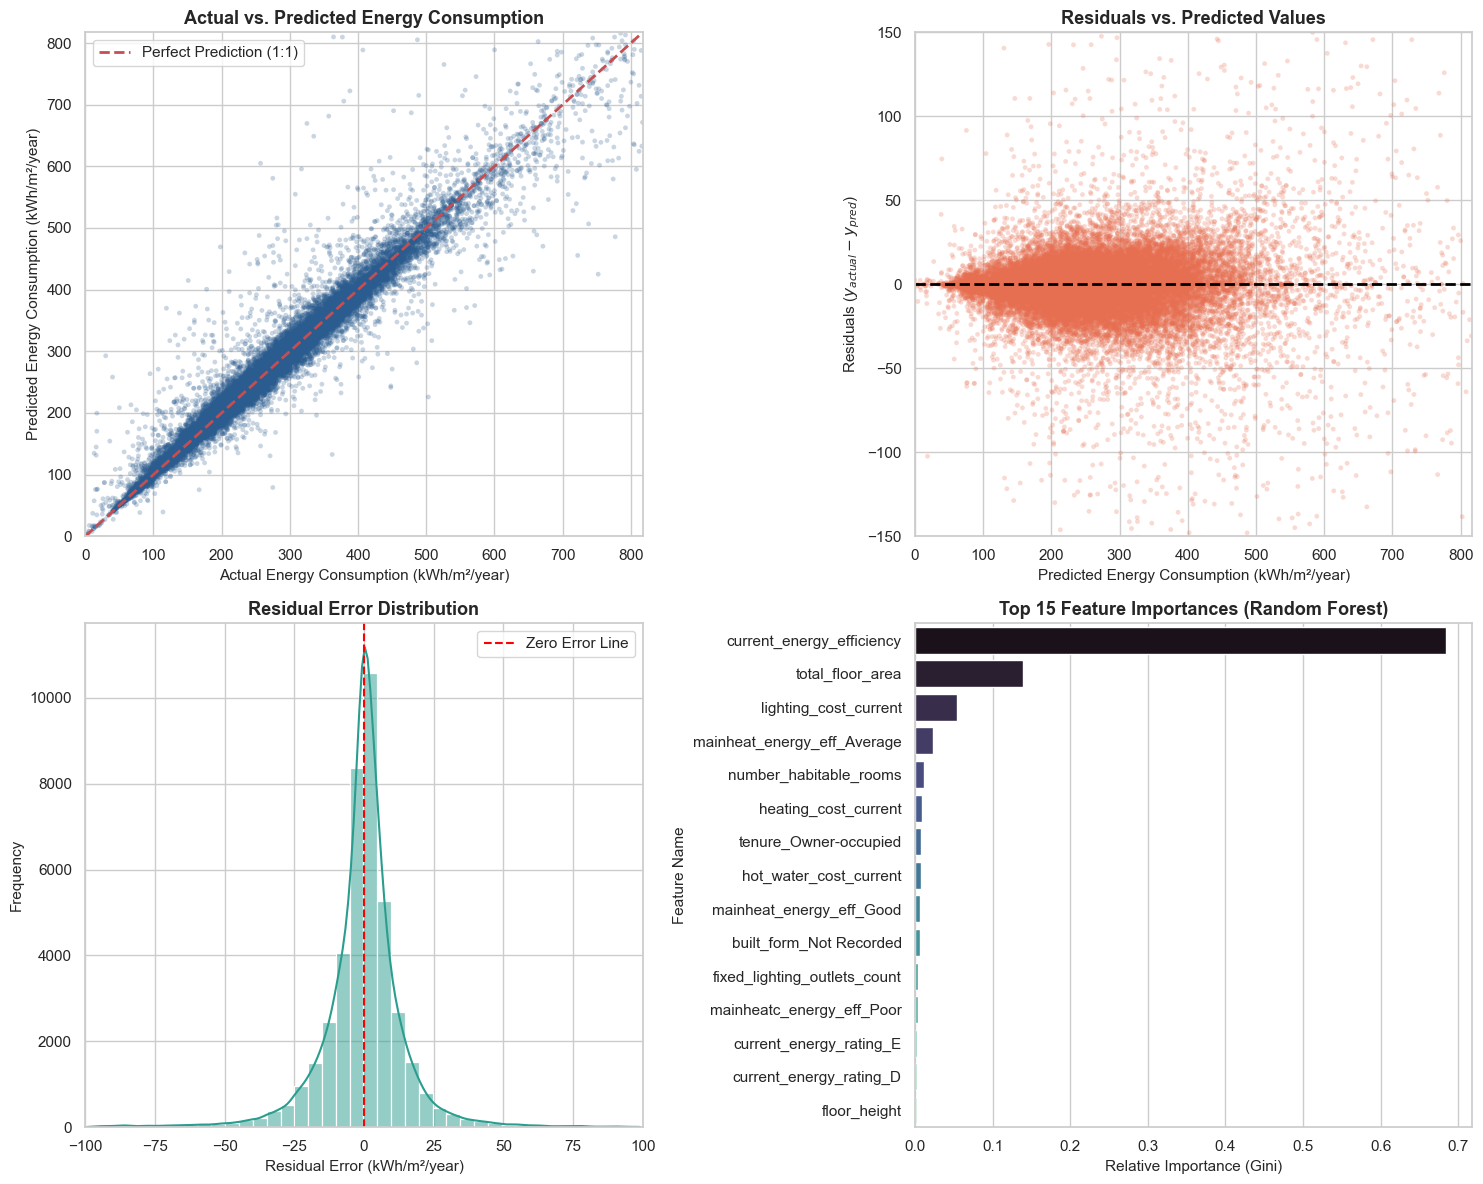

In [10]:
q_max = np.percentile(y_test, 99.8)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted
axes[0, 0].scatter(
    y_test, y_pred,
    alpha=0.25,
    color='#2b5c8f',
    s=12,
    edgecolors='none'
)

axes[0, 0].plot(
    [0, q_max], [0, q_max],
    'r--',
    lw=2,
    label='Perfect Prediction (1:1)'
)

axes[0, 0].set_title(
    'Actual vs. Predicted Energy Consumption',
    fontsize=13,
    fontweight='bold'
)
axes[0, 0].set_xlabel(
    'Actual Energy Consumption (kWh/m²/year)',
    fontsize=11
)
axes[0, 0].set_ylabel(
    'Predicted Energy Consumption (kWh/m²/year)',
    fontsize=11
)
axes[0, 0].legend(loc='upper left')
axes[0, 0].set_xlim(0, q_max)
axes[0, 0].set_ylim(0, q_max)


# 2. Residuals vs Predicted Plot
axes[0, 1].scatter(
    y_pred, residuals,
    alpha=0.25,
    color='#e76f51',
    s=12,
    edgecolors='none'
)

axes[0, 1].axhline(
    y=0,
    color='black',
    linestyle='--',
    lw=2
)

axes[0, 1].set_title(
    'Residuals vs. Predicted Values',
    fontsize=13,
    fontweight='bold'
)
axes[0, 1].set_xlabel(
    'Predicted Energy Consumption (kWh/m²/year)',
    fontsize=11
)
axes[0, 1].set_ylabel(
    'Residuals ($y_{actual} - y_{pred}$)',
    fontsize=11
)
axes[0, 1].set_xlim(0, q_max)
axes[0, 1].set_ylim(-150, 150)


# 3. Residual Error Distribution
sns.histplot(
    residuals[(residuals >= -100) & (residuals <= 100)],
    kde=True,
    ax=axes[1, 0],
    color='#2a9d8f',
    bins=40
)

axes[1, 0].axvline(
    x=0,
    color='red',
    linestyle='--',
    lw=1.5,
    label='Zero Error Line'
)

axes[1, 0].set_title(
    'Residual Error Distribution',
    fontsize=13,
    fontweight='bold'
)
axes[1, 0].set_xlabel(
    'Residual Error (kWh/m²/year)',
    fontsize=11
)
axes[1, 0].set_ylabel(
    'Frequency',
    fontsize=11
)
axes[1, 0].set_xlim(-100, 100)
axes[1, 0].legend()


# 4. Feature Importances
sns.barplot(
    data=fi_df,
    x='importance',
    y='feature',
    hue='feature',
    ax=axes[1, 1],
    palette='mako',
    legend=False
)

axes[1, 1].set_title(
    'Top 15 Feature Importances (Random Forest)',
    fontsize=13,
    fontweight='bold'
)
axes[1, 1].set_xlabel(
    'Relative Importance (Gini)',
    fontsize=11
)
axes[1, 1].set_ylabel(
    'Feature Name',
    fontsize=11
)


plt.tight_layout()

# Save figure if required
# plt.savefig('rf_evaluation_dashboard.png', dpi=300, bbox_inches='tight')

plt.show()